<a href="https://colab.research.google.com/github/JonHemrick/ECGR4106/blob/HW3/HW3_Problem1_ECGR4106.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving vast_english_french.txt to vast_english_french.txt


In [ ]:
import re
import random
import math
import time
import unicodedata
from io import open

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
PAD_token = 0
SOS_token = 1
EOS_token = 2

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "PAD", 1: "SOS", 2: "EOS"}
        self.n_words = 3

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1


def normalize_string(s, is_french=False):
    s = s.strip()
    if not is_french:
        s = ''.join(
            c for c in unicodedata.normalize('NFD', s.lower())
            if unicodedata.category(c) != 'Mn'
        )
    else:
        s = s.lower()
    s = re.sub(r"([.!?,])", r" \1", s)
    s = re.sub(r"[^a-zA-Z0-9àâäéèêëïîôöùûüç.!?,'\- ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def read_data(path):
    lines = open(path, encoding='utf-8').read().strip().split('\n')
    pairs = []
    for line in lines:
        if not line.strip():
            continue
        parts = line.split('\t')
        if len(parts) < 2:
            continue
        eng, fra = parts[0], parts[1]
        pairs.append([normalize_string(eng, is_french=False),
                       normalize_string(fra, is_french=True)])
    return pairs


DATA_PATH = "vast_english_french.txt"
pairs = read_data(DATA_PATH)
print(f"Loaded {len(pairs)} sentence pairs")
print("Example pair:", pairs[0])


Loaded 555 sentence pairs
Example pair: ['i am cold', "j'ai froid"]


In [ ]:
MAX_LENGTH = 20

pairs = [p for p in pairs if len(p[0].split(' ')) < MAX_LENGTH and len(p[1].split(' ')) < MAX_LENGTH]
print(f"{len(pairs)} pairs after length filtering")

input_lang = Lang("eng")
output_lang = Lang("fra")

for eng, fra in pairs:
    input_lang.add_sentence(eng)
    output_lang.add_sentence(fra)

print(f"English vocabulary size: {input_lang.n_words}")
print(f"French vocabulary size: {output_lang.n_words}")


555 pairs after length filtering
English vocabulary size: 1016
French vocabulary size: 1138


In [ ]:
random.shuffle(pairs)
split_idx = int(0.8 * len(pairs))
train_pairs = pairs[:split_idx]
val_pairs = pairs[split_idx:]

print(f"Training pairs: {len(train_pairs)}")
print(f"Validation pairs: {len(val_pairs)}")


Training pairs: 444
Validation pairs: 111


In [ ]:
def indexes_from_sentence(lang, sentence):
    return [lang.word2index.get(w, None) for w in sentence.split(' ')]


def tensor_from_sentence(lang, sentence):
    indexes = [lang.word2index[w] for w in sentence.split(' ') if w in lang.word2index]
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)


def tensors_from_pair(pair):
    input_tensor = tensor_from_sentence(input_lang, pair[0])
    target_tensor = tensor_from_sentence(output_lang, pair[1])
    return input_tensor, target_tensor


In [ ]:
HIDDEN_SIZE = 256

class EncoderGRU(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input_tensor, hidden):
        embedded = self.embedding(input_tensor).view(1, 1, -1)
        output, hidden = self.gru(embedded, hidden)
        return output, hidden

    def init_hidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)


class DecoderGRU(nn.Module):
    def __init__(self, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.log_softmax = nn.LogSoftmax(dim=1)
        self.relu = nn.ReLU()

    def forward(self, input_tensor, hidden):
        output = self.embedding(input_tensor).view(1, 1, -1)
        output = self.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.log_softmax(self.out(output[0]))
        return output, hidden


In [ ]:
TEACHER_FORCING_RATIO = 0.5

def train_step(input_tensor, target_tensor, encoder, decoder,
                encoder_optimizer, decoder_optimizer, criterion):
    encoder_hidden = encoder.init_hidden()
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)

    for ei in range(input_length):
        _, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)

    decoder_input = torch.tensor([[SOS_token]], device=device)
    decoder_hidden = encoder_hidden

    loss = 0
    use_teacher_forcing = random.random() < TEACHER_FORCING_RATIO

    if use_teacher_forcing:
        for di in range(target_length):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            loss += criterion(decoder_output, target_tensor[di])
            decoder_input = target_tensor[di]
    else:
        for di in range(target_length):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            topv, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze().detach().view(1, 1)
            loss += criterion(decoder_output, target_tensor[di])
            if decoder_input.item() == EOS_token:
                break

    loss.backward()
    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length


def evaluate_loss(input_tensor, target_tensor, encoder, decoder, criterion):
    with torch.no_grad():
        encoder_hidden = encoder.init_hidden()
        input_length = input_tensor.size(0)
        target_length = target_tensor.size(0)

        for ei in range(input_length):
            _, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)

        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden

        loss = 0
        for di in range(target_length):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            topv, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze().detach().view(1, 1)
            loss += criterion(decoder_output, target_tensor[di])
            if decoder_input.item() == EOS_token:
                break

        return loss.item() / target_length


In [ ]:
def run_training(encoder, decoder, n_epochs, learning_rate=0.01):
    encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss()

    train_tensors = [tensors_from_pair(p) for p in train_pairs]
    val_tensors = [tensors_from_pair(p) for p in val_pairs]

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_epoch = -1
    best_encoder_state = None
    best_decoder_state = None
    start = time.time()

    for epoch in range(1, n_epochs + 1):
        encoder.train()
        decoder.train()
        random.shuffle(train_tensors)
        total_train_loss = 0
        for input_tensor, target_tensor in train_tensors:
            total_train_loss += train_step(input_tensor, target_tensor, encoder,
                                            decoder, encoder_optimizer, decoder_optimizer, criterion)
        avg_train_loss = total_train_loss / len(train_tensors)

        encoder.eval()
        decoder.eval()
        total_val_loss = 0
        for input_tensor, target_tensor in val_tensors:
            total_val_loss += evaluate_loss(input_tensor, target_tensor, encoder, decoder, criterion)
        avg_val_loss = total_val_loss / len(val_tensors)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch
            best_encoder_state = {k: v.clone() for k, v in encoder.state_dict().items()}
            best_decoder_state = {k: v.clone() for k, v in decoder.state_dict().items()}

        elapsed = time.time() - start
        print(f"Epoch {epoch:3d}/{n_epochs} | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Elapsed: {elapsed:.1f}s")


    return train_losses, val_losses, best_encoder_state, best_decoder_state, best_epoch


In [ ]:
N_EPOCHS = 10
LEARNING_RATE = 0.01

encoder = EncoderGRU(input_lang.n_words, HIDDEN_SIZE).to(device)
decoder = DecoderGRU(HIDDEN_SIZE, output_lang.n_words).to(device)

train_losses, val_losses, best_encoder_state, best_decoder_state, best_epoch = run_training(
    encoder, decoder, N_EPOCHS, LEARNING_RATE)


final_encoder_state = {k: v.clone() for k, v in encoder.state_dict().items()}
final_decoder_state = {k: v.clone() for k, v in decoder.state_dict().items()}


Epoch   1/10 | Train Loss: 4.3457 | Val Loss: 2.8469 | Elapsed: 6.7s
Epoch   2/10 | Train Loss: 4.2650 | Val Loss: 3.5576 | Elapsed: 13.1s
Epoch   3/10 | Train Loss: 4.1362 | Val Loss: 4.3693 | Elapsed: 19.6s
Epoch   4/10 | Train Loss: 3.9806 | Val Loss: 3.7362 | Elapsed: 26.2s
Epoch   5/10 | Train Loss: 3.7547 | Val Loss: 4.1636 | Elapsed: 32.9s
Epoch   6/10 | Train Loss: 3.4211 | Val Loss: 3.8540 | Elapsed: 39.5s
Epoch   7/10 | Train Loss: 3.1444 | Val Loss: 3.6198 | Elapsed: 46.1s
Epoch   8/10 | Train Loss: 2.9655 | Val Loss: 3.8152 | Elapsed: 52.8s
Epoch   9/10 | Train Loss: 2.7110 | Val Loss: 3.8180 | Elapsed: 59.5s
Epoch  10/10 | Train Loss: 2.4508 | Val Loss: 3.8424 | Elapsed: 66.3s


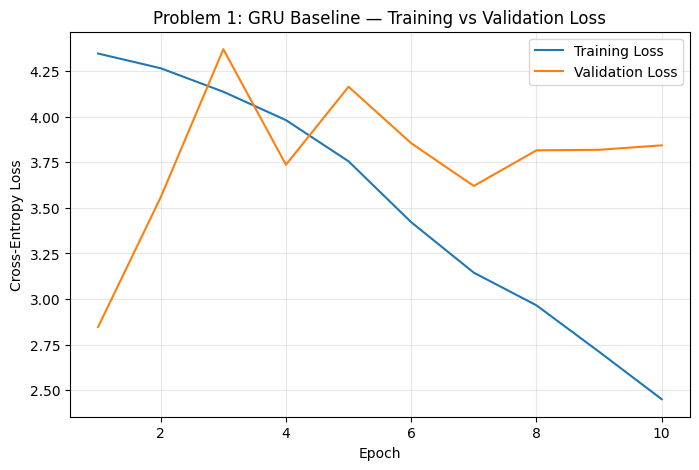

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, N_EPOCHS + 1), train_losses, label="Training Loss")
plt.plot(range(1, N_EPOCHS + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Problem 1: GRU Baseline — Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("problem1_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

smoothie = SmoothingFunction().method4

def evaluate_sentence(encoder, decoder, sentence, max_length=MAX_LENGTH):
    with torch.no_grad():
        input_tensor = tensor_from_sentence(input_lang, sentence)
        input_length = input_tensor.size(0)
        encoder_hidden = encoder.init_hidden()

        for ei in range(input_length):
            _, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)

        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden

        decoded_words = []
        for di in range(max_length):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            topv, topi = decoder_output.topk(1)
            if topi.item() == EOS_token:
                break
            else:
                decoded_words.append(output_lang.index2word[topi.item()])
            decoder_input = topi.squeeze().detach().view(1, 1)

        return decoded_words


def evaluate_full_validation_set(encoder, decoder, val_pairs):
    encoder.eval()
    decoder.eval()
    exact_matches = 0
    bleu_scores = []
    results = []

    for eng, fra in val_pairs:
        predicted_words = evaluate_sentence(encoder, decoder, eng)
        predicted_sentence = ' '.join(predicted_words)
        reference_words = fra.split(' ')

        is_exact_match = (predicted_words == reference_words)
        if is_exact_match:
            exact_matches += 1

        bleu = sentence_bleu([reference_words], predicted_words,
                              weights=(0.25, 0.25, 0.25, 0.25),
                              smoothing_function=smoothie)
        bleu_scores.append(bleu)

        results.append({
            "source": eng,
            "reference": fra,
            "predicted": predicted_sentence,
            "exact_match": is_exact_match,
            "bleu": bleu
        })

    exact_match_accuracy = exact_matches / len(val_pairs)
    avg_bleu = sum(bleu_scores) / len(bleu_scores)
    return exact_match_accuracy, avg_bleu, results


exact_match_accuracy, avg_bleu, val_results = evaluate_full_validation_set(encoder, decoder, val_pairs)

print(f"Validation Exact Sequence Match Accuracy: {exact_match_accuracy * 100:.2f}%")
print(f"Validation BLEU-4 Score: {avg_bleu:.4f}")


Validation Exact Sequence Match Accuracy: 0.00%
Validation BLEU-4 Score: 0.0651


In [ ]:
exact_match_accuracy, avg_bleu, val_results = evaluate_full_validation_set(encoder, decoder, val_pairs)

print(f"Validation Exact Sequence Match Accuracy: {exact_match_accuracy * 100:.2f}%")
print(f"Validation BLEU-4 Score: {avg_bleu:.4f}")


Validation Exact Sequence Match Accuracy: 0.00%
Validation BLEU-4 Score: 0.0651


In [ ]:
random.seed(7)
sample_results = random.sample(val_results, 5)


for i, r in enumerate(sample_results, 1):
    print(f"Sample {i}")
    print(f"  English (source):     {r['source']}")
    print(f"  Reference (target):   {r['reference']}")
    print(f"  Predicted:            {r['predicted']}")
    print(f"  Exact Match:          {r['exact_match']}")
    print(f"  BLEU-4 Score:         {r['bleu']:.4f}")



Sample 1
  English (source):     he speaks six international languages completely fluently
  Reference (target):   il parle couramment six langues internationales
  Predicted:            il parle couramment cinq langues
  Exact Match:          False
  BLEU-4 Score:         0.2635
Sample 2
  English (source):     he vacuums his entire house every friday afternoon
  Reference (target):   il passe l'aspirateur dans toute sa maison tous les vendredis après-midi
  Predicted:            il nettoie son bureau chaque soir
  Exact Match:          False
  BLEU-4 Score:         0.0163
Sample 3
  English (source):     they constructed a large stone wall around the property
  Reference (target):   ils ont construit un grand mur de pierre autour de la propriété
  Predicted:            ils écoutent la musique dans la rivière
  Exact Match:          False
  BLEU-4 Score:         0.0188
Sample 4
  English (source):     i see a plane in the sky
  Reference (target):   je vois un avion dans le ciel
  Pre